In [2]:
import pandas as pd
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import spearmanr
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from scipy import stats
from Lasso import select_features_lasso
from sklearn.inspection import permutation_importance

In [3]:
df = pd.read_csv("../datasets_prep/dm_project_dataset.csv")
df['observationTime'] = pd.to_datetime(df['observationTime'])
df.columns.to_list()

['observationTime',
 'absorbing_aerosol_index',
 'NO2_column_number_density',
 'stratospheric_NO2_column_number_density',
 'NO2_slant_column_number_density',
 'tropopause_pressure',
 'H2O_column_number_density',
 'BrO',
 'BrO_Error',
 'NO2',
 'NO2_Error',
 'O3',
 'O3_Error',
 'pm10',
 'pm2p5',
 'sia',
 'nmvoc',
 'dust',
 'nh3',
 'pans',
 'tp',
 't2m',
 'airTemperature',
 'seaLevelPressure',
 'relativeHumidity',
 'missforest_precipitation',
 'xgb_cloudCover',
 'feelsLikeTemperature_fixed',
 'windSpeed_fixed',
 'windGust_fixed',
 'windDirection_fixed']

In [4]:
cols_to_remove = ['BrO_Error', 'NO2_Error', 'O3_Error']
data = df.drop(columns = cols_to_remove)

In [5]:
data['month'] = data['observationTime'].dt.month
data['day_of_year'] = data['observationTime'].dt.dayofyear
data['day_of_week'] = data['observationTime'].dt.dayofweek

In [6]:
data['target_precipitation'] = data['missforest_precipitation'].shift(-1)
data = data.dropna(subset=['target_precipitation'])

In [7]:
r2 = r2_score(data['target_precipitation'], data['tp'])
r2

0.4183687040052195

In [8]:
def metrics_fun(y_val, rf_pred_val):
    print(f'R^2:  {r2_score(y_val, rf_pred_val)}')
    print(f'MAE:  {mean_absolute_error(y_val, rf_pred_val)}')
    print(f'RMSE: {np.sqrt(mean_squared_error(y_val, rf_pred_val))}')

    corr, p_value = stats.spearmanr(y_val, rf_pred_val)
    print(f"r_s:  {corr:.3f}")

In [9]:
train_end = '2024-02-01'
val_end = '2025-02-01'

target_col = 'target_precipitation'
drop_cols = ['missforest_precipitation','observationTime', 't2m', target_col]

In [10]:
base_features = ['absorbing_aerosol_index', 'NO2_column_number_density',
       'stratospheric_NO2_column_number_density',
       'NO2_slant_column_number_density', 'tropopause_pressure',
       'H2O_column_number_density', 'BrO', 'NO2', 'O3', 'pm10', 'pm2p5', 'sia',
       'nmvoc', 'dust', 'nh3', 'pans', 'airTemperature',
       'seaLevelPressure', 'relativeHumidity', 'xgb_cloudCover',
       'feelsLikeTemperature_fixed', 'windSpeed_fixed', 'windGust_fixed',
       'windDirection_fixed']

# Vėlavimų atrinkimas (nepasiteisinę bandymai)

In [11]:
def test_lag(data, feature_col, lag, base_features, target_col, train_end, val_end):
    df = data.copy()
    
    if lag == 0:
        features = base_features
    else:
        lag_col = f'{feature_col}_lag{lag}'
        df[lag_col] = df[feature_col].shift(lag)
        df = df.dropna().reset_index(drop=True)
        
        features = [f for f in base_features if f != feature_col] + [lag_col]
    
    train = df[df['observationTime'] < train_end]
    val   = df[(df['observationTime'] >= train_end) & (df['observationTime'] <= val_end)]
    
    model = XGBRegressor(random_state=2026)
    model.fit(train[features], train[target_col])
    
    pred = model.predict(val[features])
    return np.sqrt(mean_absolute_error(val[target_col], pred))


results = []
for col in base_features:
    for lag in range(0, 10):  # 0 = originali
        mae = test_lag(data, col, lag, base_features, 'target_precipitation', train_end, val_end)
        label = 'originali' if lag == 0 else f'lag{lag}'
        results.append({'feature': col, 'lag': lag, 'label': label, 'mae': mae})
        print(f"{col} {label}: MAE = {mae:.4f}")

results_df = pd.DataFrame(results)

print("\n=== Suvestinė ===")
for col in results_df['feature'].unique():
    subset = results_df[results_df['feature'] == col]
    best = subset.loc[subset['mae'].idxmin()]
    orig_mae = subset[subset['lag'] == 0]['mae'].values[0]
    print(f"\n{col}:")
    print(f"  Originali : {orig_mae:.4f}")
    print(f"  Geriausias: {best['label']} → {best['mae']:.4f}")

absorbing_aerosol_index originali: MAE = 1.5937
absorbing_aerosol_index lag1: MAE = 1.6151
absorbing_aerosol_index lag2: MAE = 1.6083
absorbing_aerosol_index lag3: MAE = 1.6302
absorbing_aerosol_index lag4: MAE = 1.6024
absorbing_aerosol_index lag5: MAE = 1.5976
absorbing_aerosol_index lag6: MAE = 1.6180
absorbing_aerosol_index lag7: MAE = 1.5924
absorbing_aerosol_index lag8: MAE = 1.5402
absorbing_aerosol_index lag9: MAE = 1.6155
NO2_column_number_density originali: MAE = 1.5937
NO2_column_number_density lag1: MAE = 1.7118
NO2_column_number_density lag2: MAE = 1.6707
NO2_column_number_density lag3: MAE = 1.6717
NO2_column_number_density lag4: MAE = 1.6825
NO2_column_number_density lag5: MAE = 1.6181
NO2_column_number_density lag6: MAE = 1.6892
NO2_column_number_density lag7: MAE = 1.6777
NO2_column_number_density lag8: MAE = 1.7222
NO2_column_number_density lag9: MAE = 1.7406
stratospheric_NO2_column_number_density originali: MAE = 1.5937
stratospheric_NO2_column_number_density lag1: 

In [12]:

def add_specific_lags(df):
    df = df.copy()
    
    # df['absorbing_aerosol_index_lag6'] = df['absorbing_aerosol_index'].shift(6)
    # df['NO2_column_number_density_lag11'] = df['NO2_column_number_density'].shift(11)
    # df['stratospheric_NO2_column_number_density_lag10'] = df['stratospheric_NO2_column_number_density'].shift(10)
    # df['NO2_slant_column_number_density_lag1'] = df['NO2_slant_column_number_density'].shift(1)
    # df['tropopause_pressure_lag8'] = df['tropopause_pressure'].shift(8)
    # df['H2O_column_number_density_lag10'] = df['H2O_column_number_density'].shift(10)
    # df['BrO_lag5'] = df['BrO'].shift(5)
    # df['NO2_lag10'] = df['NO2'].shift(10)
    # df['O3_lag4'] = df['O3'].shift(4)
    # df['pm10_lag8'] = df['pm10'].shift(8)
    # df['pm2p5_lag3'] = df['pm2p5'].shift(3)
    # df['sia_lag5'] = df['sia'].shift(5)
    # df['nmvoc_lag9'] = df['nmvoc'].shift(9)
    # df['dust_lag9'] = df['dust'].shift(9)
    # df['nh3_lag9'] = df['nh3'].shift(9)
    # df['pans_lag2'] = df['pans'].shift(2)
    # df['airTemperature_lag9'] = df['airTemperature'].shift(9)
    # df['seaLevelPressure_lag1'] = df['seaLevelPressure'].shift(1)
    # df['relativeHumidity_lag_lag10'] = df['relativeHumidity'].shift(10)
    # df['xgb_cloudCover_lag3'] = df['xgb_cloudCover'].shift(3)
    # df['feelsLikeTemperature_fixed_lag10'] = df['feelsLikeTemperature_fixed'].shift(10)
    # df['windSpeed_fixed_lag1'] = df['windSpeed_fixed'].shift(1)
    # df['windGust_fixed_lag8'] = df['windGust_fixed'].shift(8)
    # df['windDirection_fixed_lag6'] = df['windDirection_fixed'].shift(6)

    
    
    return df

data_with_lags = add_specific_lags(data)
data_with_lags = data_with_lags.dropna().reset_index(drop=True)

In [13]:
original_pollutants = [
    # 'absorbing_aerosol_index',
    # 'NO2_column_number_density',
    # 'stratospheric_NO2_column_number_density',
    # 'NO2_slant_column_number_density',
    # 'tropopause_pressure',
    # 'H2O_column_number_density',
    # 'BrO',
    # 'NO2',
    # 'O3',
    # 'pm10',
    # 'pm2p5',
    # 'sia',
    # 'nmvoc',
    # 'dust',
    # 'nh3',
    # 'pans',
    # 'airTemperature',
    # 'seaLevelPressure',
    # 'relativeHumidity',
    # 'xgb_cloudCover',
    # 'feelsLikeTemperature_fixed',
    # 'windSpeed_fixed',
    # 'windGust_fixed',
    # 'windDirection_fixed'
]

data_with_lags = data_with_lags.drop(columns=original_pollutants)

In [14]:
train = data_with_lags[data_with_lags['observationTime'] < train_end]
val   = data_with_lags[(data_with_lags['observationTime'] >= train_end) & (data_with_lags['observationTime'] <= val_end)]
test  = data_with_lags[data_with_lags['observationTime'] > val_end]

print(f"Train: {train.shape}, nuo {train['observationTime'].min()} iki {train['observationTime'].max()}")
print(f"Val: {val.shape}, nuo {val['observationTime'].min()} iki {val['observationTime'].max()}")
print(f"Test:  {test.shape},  nuo {test['observationTime'].min()} iki {test['observationTime'].max()}")

Train: (2041, 32), nuo 2018-07-01 00:00:00 iki 2024-01-31 00:00:00
Val: (367, 32), nuo 2024-02-01 00:00:00 iki 2025-02-01 00:00:00
Test:  (363, 32),  nuo 2025-02-02 00:00:00 iki 2026-01-30 00:00:00


In [15]:
X_train = train.drop(columns=drop_cols)
y_train = train[target_col]

X_val = val.drop(columns=drop_cols)
y_val = val[target_col]

X_test = test.drop(columns=drop_cols)
y_test = test[target_col]

In [72]:
# train_for_lasso = X_train.copy()
# train_for_lasso[target_col] = y_train

# selected_features = select_features_lasso(train_for_lasso, target_col)


# X_train_selected = X_train[selected_features]
# X_val_selected   = X_val[selected_features]
# X_test_selected  = X_test[selected_features]

# stand_model = XGBRegressor(random_state=2026)
# stand_model.fit(X_train_selected, y_train)

# val_preds_stand = stand_model.predict(X_val_selected)
# metrics_fun(y_val, val_preds_stand)

Pradinis požymių skaičius: 28
Išlikusių požymių skaičius: 7
Geriausias lambda (alpha): 0.1261
Pašalinti požymiai: ['BrO_lag5', 'day_of_week', 'relativeHumidity_lag_lag10', 'absorbing_aerosol_index_lag6', 'day_of_year', 'dust_lag9', 'pm10_lag8', 'month', 'windGust_fixed_lag8', 'H2O_column_number_density_lag10', 'NO2', 'windSpeed_fixed_lag1', 'airTemperature_lag9', 'windDirection_fixed_lag6', 'seaLevelPressure_lag1', 'O3_lag4', 'xgb_cloudCover_lag3', 'nh3', 'nmvoc_lag9', 'NO2_slant_column_number_density_lag1', 'sia_lag5']
R^2:  0.21213388825778112
MAE:  1.663987748211945
RMSE: 4.285939584478237
r_s:  0.626


In [ ]:
import optuna

def objective(trial):
    df = data.copy()
    features = list(base_features)
    
    for col in base_features:
        lag = trial.suggest_int(f'lag_{col}', 0, 10)
        if lag > 0:
            lag_col = f'{col}_lag{lag}'
            df[lag_col] = df[col].shift(lag)
            features = [f for f in features if f != col] + [lag_col]
    
    df = df.dropna().reset_index(drop=True)
    
    train = df[df['observationTime'] < train_end]
    val   = df[(df['observationTime'] >= train_end) & (df['observationTime'] <= val_end)]
    
    model = XGBRegressor(random_state=2026)
    model.fit(train[features], train[target_col])
    pred = model.predict(val[features])
    
    return mean_absolute_error(val[target_col], pred)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=200, show_progress_bar=True)

print("Geriausi lagai:")
print(study.best_params)

In [90]:
def build_best_features(data, best_params, base_features):
    df = data.copy()
    features = list(base_features)
    
    for col in base_features:
        lag    = best_params.get(f'lag_{col}', 0)
        window = best_params.get(f'roll_{col}', 0)
        
        if lag > 0:
            lag_col = f'{col}_lag{lag}'
            df[lag_col] = df[col].shift(lag)
            features = [f for f in features if f != col] + [lag_col]
        
        if window > 1:
            roll_col = f'{col}_roll_mean_{window}'
            df[roll_col] = df[col].shift(1).rolling(window).mean()
            features = features + [roll_col]
    
    df = df.dropna().reset_index(drop=True)
    return df, features


data_best, best_features = build_best_features(data, study.best_params, base_features)

train = data_best[data_best['observationTime'] < train_end]
val   = data_best[(data_best['observationTime'] >= train_end) & (data_best['observationTime'] <= val_end)]
test  = data_best[data_best['observationTime'] > val_end]

X_train = train[best_features]
y_train = train[target_col]

X_val = val[best_features]
y_val = val[target_col]

X_test = test[best_features]
y_test = test[target_col]

final_model = XGBRegressor(random_state=2026)
final_model.fit(X_train, y_train)

print("Val rezultatai:")
metrics_fun(y_val, final_model.predict(X_val))

Val rezultatai:
R^2:  0.19492067807752267
MAE:  2.2650761206186445
RMSE: 4.332505977352503
r_s:  0.270


# Vėlavimų atrinkimas

In [16]:
def add_all_lags(df, base_features, max_lag=15):
    df = df.copy()
    new_cols = {}
    
    for col in base_features:
        for lag in range(1, max_lag + 1):
            new_cols[f'{col}_lag{lag}'] = df[col].shift(lag)
    
    df = pd.concat([df, pd.DataFrame(new_cols)], axis=1)
    return df.dropna().reset_index(drop=True)

def add_all_rolling(df, base_features, windows=[3, 7, 14, 30]):
    df = df.copy()
    new_cols = {}
    
    for col in base_features:
        for w in windows:
            new_cols[f'{col}_roll_mean_{w}'] = df[col].shift(1).rolling(w).mean()
            new_cols[f'{col}_roll_std_{w}']  = df[col].shift(1).rolling(w).std()
            new_cols[f'{col}_roll_max_{w}']  = df[col].shift(1).rolling(w).max()
            new_cols[f'{col}_roll_min_{w}']  = df[col].shift(1).rolling(w).min()
    
    df = pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)
    return df.dropna().reset_index(drop=True)

# data_rolled = add_all_rolling(data, base_features, windows=[3, 7, 14, 30])
# print(f"Požymių skaičius su rolling: {data_rolled.shape[1]}")

# data_lagged = add_all_lags(data, base_features, max_lag=14)
# print(f"Požymių skaičius su lagais: {data_lagged.shape[1]}")

data_all = add_all_lags(data, base_features, max_lag=14)
data_lagged = add_all_rolling(data_all, base_features, windows=[7, 14])
print(f"Viso požymių: {data_lagged.shape[1]}")

Viso požymių: 560


In [307]:
train = data_lagged[data_lagged['observationTime'] < train_end]
val   = data_lagged[(data_lagged['observationTime'] >= train_end) & (data_lagged['observationTime'] <= val_end)]
test  = data_lagged[data_lagged['observationTime'] > val_end]

drop_cols = ['observationTime', 'target_precipitation', 'missforest_precipitation', 't2m']

X_train = train.drop(columns=drop_cols)
y_train = train[target_col]

X_val = val.drop(columns=drop_cols)
y_val = val[target_col]

X_test = test.drop(columns=drop_cols)
y_test = test[target_col]

print(f"Train: {X_train.shape}")
print(f"Val:   {X_val.shape}")

Train: (2013, 556)
Val:   (367, 556)


In [308]:
corr = pd.concat([X_train, y_train], axis=1).corr()[target_col].abs()
corr = corr.drop(target_col)
candidates = corr[corr > 0.03].index.tolist()

print(f"\nPo koreliacijos filtro (>0.03): {len(candidates)} požymių")

X_train_filtered = X_train[candidates]
X_val_filtered   = X_val[candidates]


Po koreliacijos filtro (>0.03): 283 požymių


In [309]:
model = XGBRegressor(random_state=2026)
model.fit(X_train_filtered, y_train)

# val_pred = model.predict(X_val_filtered)

perm = permutation_importance(
    model, X_val_filtered, y_val,
    n_repeats=10,
    random_state=2026,
    scoring='neg_mean_absolute_error'
)

perm_df = pd.DataFrame({
    'feature':    X_val_filtered.columns,
    'importance': perm.importances_mean,
    'std':        perm.importances_std
}).sort_values('importance', ascending=False)

print("\nPermutation Importance:")
print(perm_df.to_string(index=False))


Permutation Importance:
                                             feature  importance      std
                                                  tp    0.880784 0.073591
                           H2O_column_number_density    0.060775 0.022108
       stratospheric_NO2_column_number_density_lag13    0.033258 0.013185
                                          pm10_lag13    0.029334 0.058544
       stratospheric_NO2_column_number_density_lag14    0.026811 0.006660
                                            nh3_lag1    0.021698 0.006341
                                                pm10    0.021165 0.028551
                     H2O_column_number_density_lag13    0.020375 0.008354
                                            nh3_lag6    0.020272 0.008160
                                     nh3_roll_max_14    0.019652 0.004599
                                 tropopause_pressure    0.018521 0.008886
                                            nh3_lag2    0.017501 0.019695
             

In [310]:
final_features = perm_df[perm_df['importance'] > 0]['feature'].tolist()
print(f"\nGalutiniai požymiai ({len(final_features)}):")
print(final_features)


Galutiniai požymiai (151):
['tp', 'H2O_column_number_density', 'stratospheric_NO2_column_number_density_lag13', 'pm10_lag13', 'stratospheric_NO2_column_number_density_lag14', 'nh3_lag1', 'pm10', 'H2O_column_number_density_lag13', 'nh3_lag6', 'nh3_roll_max_14', 'tropopause_pressure', 'nh3_lag2', 'H2O_column_number_density_lag1', 'stratospheric_NO2_column_number_density_lag10', 'nh3_lag11', 'O3_roll_std_7', 'O3_roll_std_14', 'nmvoc_lag14', 'windGust_fixed', 'windSpeed_fixed_roll_std_14', 'NO2_slant_column_number_density_lag6', 'stratospheric_NO2_column_number_density_lag12', 'nh3_lag14', 'nh3', 'stratospheric_NO2_column_number_density_lag8', 'H2O_column_number_density_lag7', 'pm10_roll_std_7', 'pm2p5_lag7', 'BrO_lag3', 'stratospheric_NO2_column_number_density_lag3', 'BrO_lag6', 'windSpeed_fixed_roll_max_7', 'seaLevelPressure_lag2', 'BrO_lag13', 'windDirection_fixed_lag1', 'airTemperature_lag8', 'NO2_lag5', 'sia_lag6', 'nh3_lag7', 'NO2_lag7', 'NO2_lag9', 'BrO_lag12', 'tropopause_pressure

In [311]:
X_train_perm_all_lag = X_train_filtered[final_features]
X_val_perm_all_lag   = X_val_filtered[final_features]
X_test_perm_all_lag  = X_test[final_features]

final_model = XGBRegressor(random_state=2026)
final_model.fit(X_train_perm_all_lag, y_train)

print("\n=== GALUTINIAI REZULTATAI ===")
print("Val:")
metrics_fun(y_val, final_model.predict(X_val_perm_all_lag))


=== GALUTINIAI REZULTATAI ===
Val:
R^2:  0.2830318928951986
MAE:  1.7215827789938911
RMSE: 4.088554141815581
r_s:  0.603


## Lasso

In [312]:
train_for_lasso = X_train_filtered.copy()
train_for_lasso[target_col] = y_train

lasso_features = select_features_lasso(train_for_lasso, target_col)

X_train_lasso = X_train_filtered[lasso_features]
X_val_lasso   = X_val[lasso_features]

# Modelis su Lasso požymiais
model = XGBRegressor(random_state=2026)
model.fit(X_train_lasso, y_train)

print(f"MAE po Lasso: {mean_absolute_error(y_val, model.predict(X_val_lasso)):.4f}")

# Permutation importance
perm = permutation_importance(
    model, X_val_lasso, y_val,
    n_repeats=10,
    random_state=2026,
    scoring='neg_mean_absolute_error'
)

perm_df = pd.DataFrame({
    'feature':    lasso_features,
    'importance': perm.importances_mean,
}).sort_values('importance', ascending=False)

final_features = perm_df[perm_df['importance'] > 0]['feature'].tolist()
print(f"\nPo Permutation: {len(final_features)} požymių")
print(perm_df[perm_df['importance'] > 0].to_string(index=False))


final_model = XGBRegressor(random_state=2026)
final_model.fit(X_train[final_features], y_train)

print(f"\nMAE galutinis: {mean_absolute_error(y_val, final_model.predict(X_val[final_features])):.4f}")

print("Val:")
metrics_fun(y_val, final_model.predict(X_val[final_features]))

Pradinis požymių skaičius: 283
Išlikusių požymių skaičius: 26
Geriausias lambda (alpha): 0.1013
Pašalinti požymiai: ['NO2_lag3', 'airTemperature_lag13', 'seaLevelPressure_roll_max_14', 'stratospheric_NO2_column_number_density_lag8', 'nmvoc_lag1', 'pm2p5_roll_mean_14', 'O3_lag8', 'dust_lag7', 'airTemperature_lag11', 'NO2_slant_column_number_density_lag9', 'H2O_column_number_density_roll_max_7', 'windSpeed_fixed_roll_max_7', 'NO2_column_number_density_roll_min_7', 'pm10_roll_std_7', 'NO2_roll_std_7', 'BrO_lag8', 'seaLevelPressure_roll_min_7', 'airTemperature_lag4', 'feelsLikeTemperature_fixed_lag6', 'NO2_lag9', 'pm10_roll_std_14', 'BrO_lag2', 'H2O_column_number_density_roll_min_14', 'sia_roll_std_14', 'pans_lag3', 'stratospheric_NO2_column_number_density_lag5', 'dust_roll_std_7', 'NO2_column_number_density_roll_std_14', 'stratospheric_NO2_column_number_density_lag11', 'NO2_slant_column_number_density_lag14', 'sia_roll_max_7', 'windSpeed_fixed_lag5', 'feelsLikeTemperature_fixed_lag9', 'pm

# RFE

In [313]:
from sklearn.feature_selection import RFECV
from sklearn.model_selection import TimeSeriesSplit

def select_features_rfe(X_train, y_train, n_splits=5):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    
    estimator = XGBRegressor(random_state=2026)
    
    rfe = RFECV(
        estimator=estimator,
        step=3,
        cv=tscv,
        scoring='neg_mean_absolute_error',
        min_features_to_select=20,
        n_jobs=-1
    )
    rfe.fit(X_train, y_train)
    
    selected_features = X_train.columns[rfe.support_].tolist()
    
    print(f"Pradinis požymių skaičius: {X_train.shape[1]}")
    print(f"Išlikusių požymių skaičius: {len(selected_features)}")
    print(f"Pašalinti požymiai: {list(set(X_train.columns) - set(selected_features))}")
    
    return selected_features

rfe_features = select_features_rfe(X_train_filtered, y_train)

X_train_rfe = X_train_filtered[rfe_features]
X_val_rfe   = X_val[rfe_features]

model = XGBRegressor(random_state=2026)
model.fit(X_train_rfe, y_train)

print(f"MAE po RFE: {mean_absolute_error(y_val, model.predict(X_val_rfe)):.4f}")

perm = permutation_importance(
    model, X_val_rfe, y_val,
    n_repeats=10,
    random_state=2026,
    scoring='neg_mean_absolute_error'
)

perm_df = pd.DataFrame({
    'feature':    rfe_features,
    'importance': perm.importances_mean,
}).sort_values('importance', ascending=False)

final_features = perm_df[perm_df['importance'] > 0]['feature'].tolist()
print(f"\nPo Permutation: {len(final_features)} požymių")
print(perm_df[perm_df['importance'] > 0].to_string(index=False))

final_model = XGBRegressor(random_state=2026)
final_model.fit(X_train_filtered[final_features], y_train)

print(f"\nMAE galutinis: {mean_absolute_error(y_val, final_model.predict(X_val[final_features])):.4f}")

print("Val:")
metrics_fun(y_val, final_model.predict(X_val[final_features]))

Pradinis požymių skaičius: 283
Išlikusių požymių skaičius: 31
Pašalinti požymiai: ['NO2_lag3', 'airTemperature_lag13', 'seaLevelPressure_roll_max_14', 'stratospheric_NO2_column_number_density_lag8', 'nmvoc_lag1', 'O3_lag8', 'dust_lag7', 'airTemperature_lag11', 'NO2_slant_column_number_density_lag9', 'H2O_column_number_density_roll_max_7', 'NO2_column_number_density_roll_min_7', 'pm10_roll_std_7', 'BrO_lag8', 'seaLevelPressure_roll_min_7', 'airTemperature_lag4', 'feelsLikeTemperature_fixed_lag6', 'NO2_lag9', 'pm10_roll_std_14', 'BrO_lag2', 'H2O_column_number_density_roll_min_14', 'sia_roll_std_14', 'pans_lag3', 'stratospheric_NO2_column_number_density_lag5', 'dust_roll_std_7', 'NO2_column_number_density_roll_std_14', 'stratospheric_NO2_column_number_density_lag11', 'NO2_slant_column_number_density_lag14', 'sia_roll_max_7', 'windSpeed_fixed_lag5', 'feelsLikeTemperature_fixed_lag9', 'pm10_lag8', 'nmvoc_lag2', 'nh3_lag13', 'H2O_column_number_density_roll_mean_14', 'BrO_lag11', 'feelsLikeTe

# Atrinkimas ranka

In [17]:
def add_specific_lags(df):
    df = df.copy()
    
    # df['absorbing_aerosol_index_lag8'] = df['absorbing_aerosol_index'].shift(8)
    # df['NO2_column_number_density_lag1'] = df['NO2_column_number_density'].shift(1)
    # df['stratospheric_NO2_column_number_density_lag10'] = df['stratospheric_NO2_column_number_density'].shift(10)
    df['NO2_slant_column_number_density_lag1'] = df['NO2_slant_column_number_density'].shift(1)
    df['tropopause_pressure_lag1'] = df['tropopause_pressure'].shift(1)
    df['H2O_column_number_density_lag1'] = df['H2O_column_number_density'].shift(1)
    # df['BrO_lag11'] = df['BrO'].shift(11)
    df['NO2_lag9'] = df['NO2'].shift(9)
    df['O3_lag1'] = df['O3'].shift(1)
    df['pm10_lag5'] = df['pm10'].shift(5)
    # df['pm2p5_lag11'] = df['pm2p5'].shift(11)
    # df['sia_lag11'] = df['sia'].shift(11)
    df['nmvoc_lag1'] = df['nmvoc'].shift(1)
    # df['dust_lag4'] = df['dust'].shift(4)
    # df['nh3_lag11'] = df['nh3'].shift(11)
    # df['pans_lag6'] = df['pans'].shift(6)
    df['airTemperature_lag10'] = df['airTemperature'].shift(10)
    # df['seaLevelPressure_lag4'] = df['seaLevelPressure'].shift(4)
    df['relativeHumidity_lag_lag4'] = df['relativeHumidity'].shift(4)
    # df['xgb_cloudCover_lag3'] = df['xgb_cloudCover'].shift(3)
    df['feelsLikeTemperature_fixed_lag3'] = df['feelsLikeTemperature_fixed'].shift(3)
    # df['windSpeed_fixed_lag1'] = df['windSpeed_fixed'].shift(1)
    # df['windGust_fixed_lag3'] = df['windGust_fixed'].shift(3)
    # df['windDirection_fixed_lag10'] = df['windDirection_fixed'].shift(10)

    # df['pm10_mean_7'] = df['pm10'].shift(1).rolling(window=7).mean()

    
    return df

data_with_lags = add_specific_lags(data)
data_with_lags = data_with_lags.dropna().reset_index(drop=True)

original_pollutants = [
    # 'absorbing_aerosol_index',
    # 'NO2_column_number_density',
    # 'stratospheric_NO2_column_number_density',
    'NO2_slant_column_number_density',
    'tropopause_pressure',
    'H2O_column_number_density',
    # 'BrO',
    'NO2',
    'O3',
    'pm10',
    # 'pm2p5',
    # 'sia',
    'nmvoc',
    # 'dust',
    # 'nh3',
    # 'pans',
    'airTemperature',
    # 'seaLevelPressure',
    'relativeHumidity',
    # 'xgb_cloudCover',
    'feelsLikeTemperature_fixed',
    # 'windSpeed_fixed',
    # 'windGust_fixed',
    # 'windDirection_fixed'
]

data_with_lags = data_with_lags.drop(columns=original_pollutants)

In [18]:
train = data_with_lags[data_with_lags['observationTime'] < train_end]
val   = data_with_lags[(data_with_lags['observationTime'] >= train_end) & (data_with_lags['observationTime'] <= val_end)]
test  = data_with_lags[data_with_lags['observationTime'] > val_end]

X_train = train.drop(columns=drop_cols)
y_train = train[target_col]

X_val = val.drop(columns=drop_cols)
y_val = val[target_col]

X_test = test.drop(columns=drop_cols)
y_test = test[target_col]

final_model = XGBRegressor(random_state=2026)
final_model.fit(X_train, y_train)

perm = permutation_importance(
    final_model, X_val, y_val,
    n_repeats=10,
    random_state=2026,
    scoring='neg_mean_absolute_error'
)

perm_df = pd.DataFrame({
    'feature':    X_val.columns,
    'importance': perm.importances_mean,
    'std':        perm.importances_std
}).sort_values('importance', ascending=False)

print("\nPermutation Importance:")
print(perm_df.to_string(index=False))

print("Val rezultatai:")
metrics_fun(y_val, final_model.predict(X_val))


Permutation Importance:
                                feature  importance      std
                                     tp    1.026655 0.107885
         H2O_column_number_density_lag1    0.194264 0.049461
                   airTemperature_lag10    0.073418 0.052830
              NO2_column_number_density    0.071069 0.020324
                         xgb_cloudCover    0.045561 0.027802
                               NO2_lag9    0.038512 0.008134
                                   dust    0.037771 0.027768
                                    BrO    0.037306 0.019906
                                    nh3    0.033318 0.023707
                            day_of_year    0.030382 0.035090
                    windDirection_fixed    0.029536 0.016221
                                O3_lag1    0.029077 0.008379
                              pm10_lag5    0.026903 0.015072
        feelsLikeTemperature_fixed_lag3    0.024441 0.010162
              relativeHumidity_lag_lag4    0.022809 0.005861

# Standartiniai hiperparametrai

In [19]:
val_preds= final_model.predict(X_val)

metrics_fun(y_val, val_preds)

R^2:  0.5409063769139836
MAE:  1.5300278053545375
RMSE: 3.271677329722429
r_s:  0.609


In [20]:
plot_df = val[['observationTime', 'target_precipitation']].copy()
plot_df['prediction'] = val_preds
plot_df = plot_df.sort_values('observationTime')

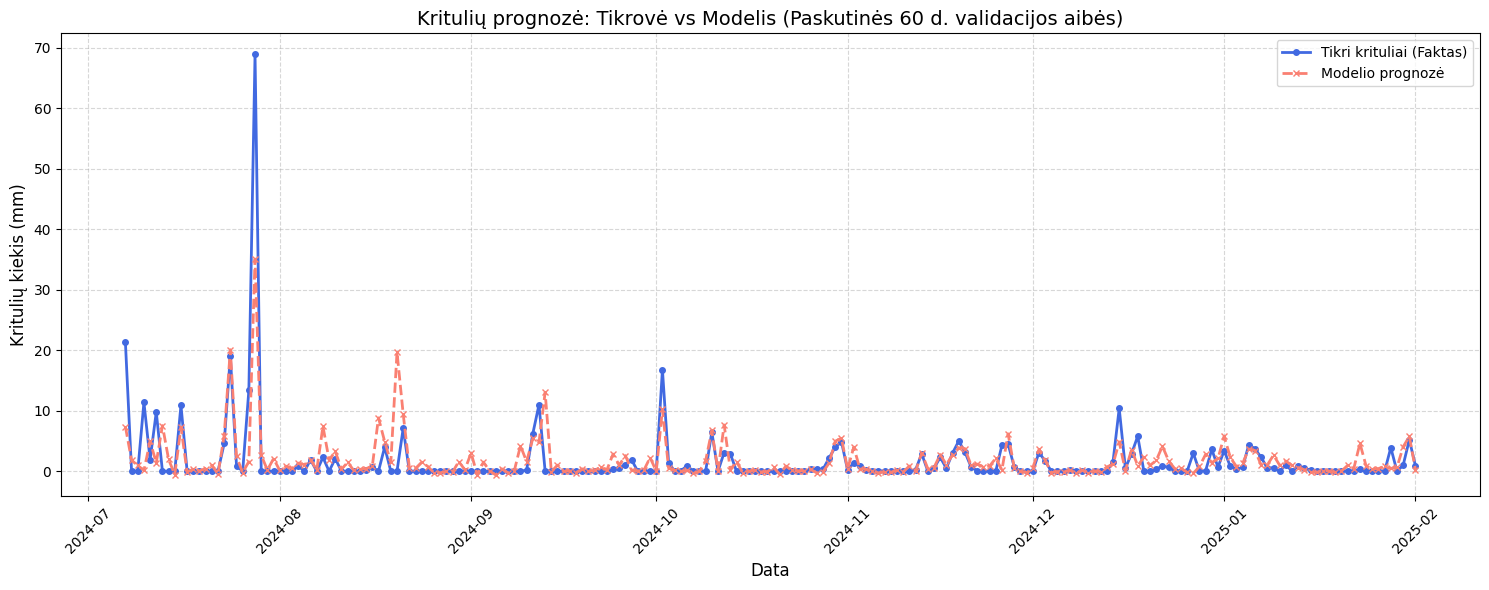

In [21]:
recent_df = plot_df.tail(210)

plt.figure(figsize=(15, 6))

# Tikri krituliai
plt.plot(recent_df['observationTime'], recent_df['target_precipitation'], 
         label='Tikri krituliai (Faktas)', color='royalblue', linewidth=2, marker='o', markersize=4)

# Modelio prognozė
plt.plot(recent_df['observationTime'], recent_df['prediction'], 
         label='Modelio prognozė', color='salmon', linestyle='--', linewidth=2, marker='x', markersize=4)

plt.title('Kritulių prognozė: Tikrovė vs Modelis (Paskutinės 60 d. validacijos aibės)', fontsize=14)
plt.ylabel('Kritulių kiekis (mm)', fontsize=12)
plt.xlabel('Data', fontsize=12)
plt.xticks(rotation=45) 
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

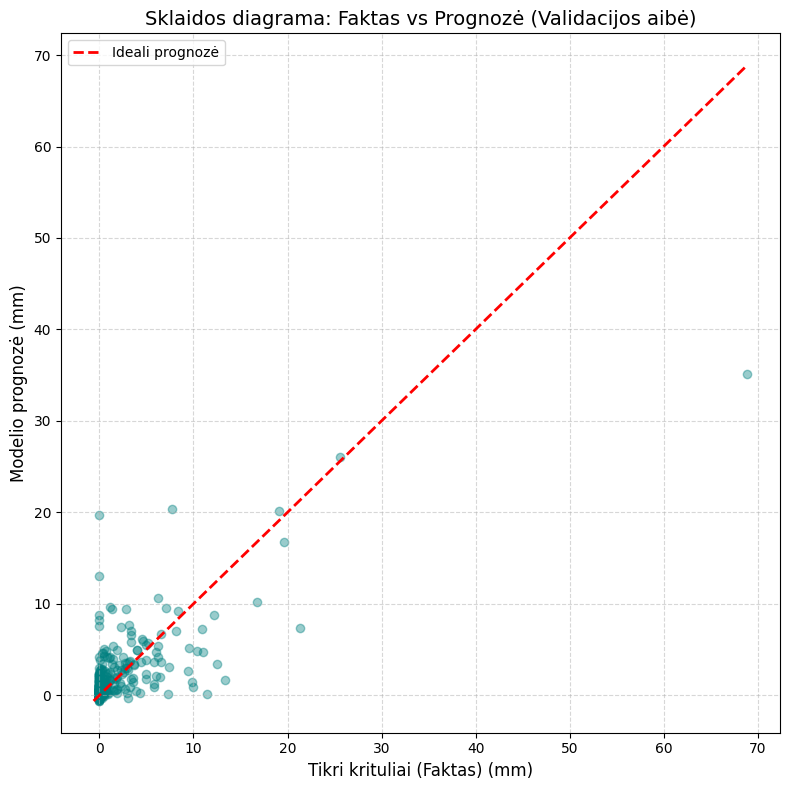

In [22]:
plt.figure(figsize=(8, 8))

plt.scatter(plot_df['target_precipitation'], plot_df['prediction'], alpha=0.4, color='teal')

max_val = max(plot_df['target_precipitation'].max(), plot_df['prediction'].max())
min_val = min(plot_df['target_precipitation'].min(), plot_df['prediction'].min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Ideali prognozė')

plt.title('Sklaidos diagrama: Faktas vs Prognozė (Validacijos aibė)', fontsize=14)
plt.xlabel('Tikri krituliai (Faktas) (mm)', fontsize=12)
plt.ylabel('Modelio prognozė (mm)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

<Figure size 1000x800 with 0 Axes>

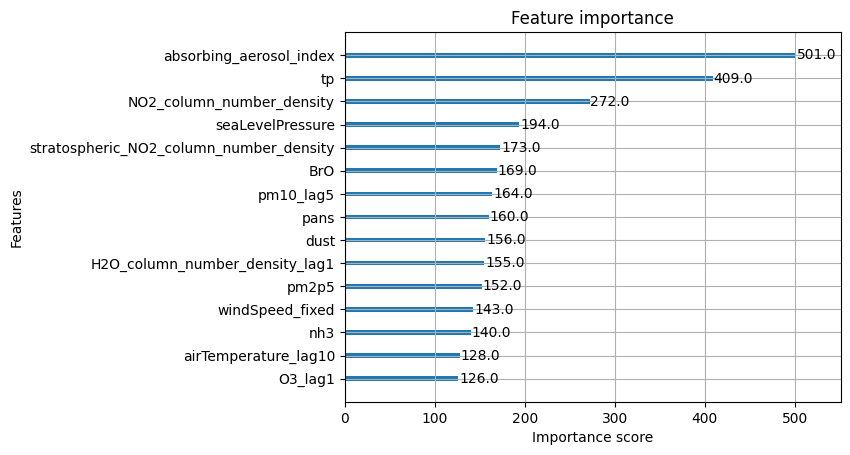

In [371]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plt.figure(figsize=(10, 8))
plot_importance(final_model, max_num_features=15, importance_type='weight') 
plt.show()

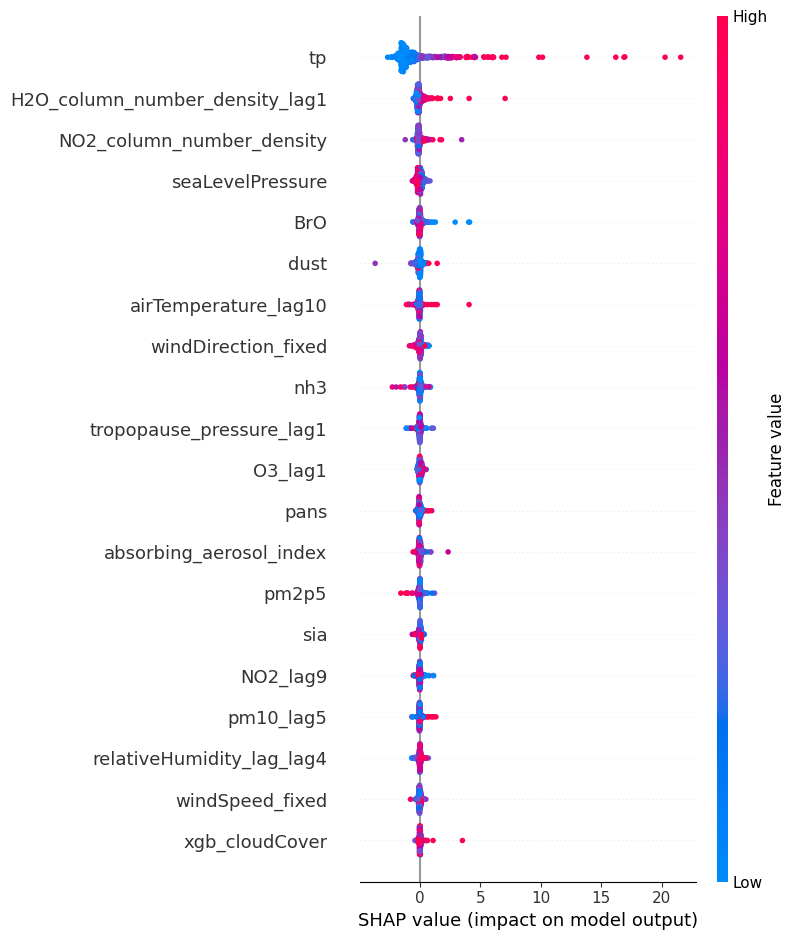

In [372]:
import shap

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_val)
shap.summary_plot(shap_values, X_val)

## Hiperparametru atrinkimas

In [73]:
tscv = TimeSeriesSplit(n_splits=5)

# param_grid = {
#     'n_estimators': [700, 750, 800, 850, 900],
#     'learning_rate': [0.001, 0.003, 0.005, 0.006, 0.01],
#     'max_depth': [2, 3, 4, 6],
#     'subsample': [0.5, 0.55, 0.6, 0.65, 0.7],
#     'min_split_loss':[14, 16, 18, 20]
# }

param_grid = {
    'n_estimators': [700, 800, 900, 1000, 1100, 1200],
    'learning_rate': [0.003, 0.005, 0.006],
    'max_depth': [4, 5, 6, 7, 8],
    'subsample': [0.2, 0.3, 0.4],
    'min_split_loss':[26, 28, 30, 32, 34, 36, 38]
}

# param_grid = {
#     'n_estimators': [300, 400, 600, 800, 900],
#     'learning_rate': [0.001, 0.005, 0.01, 0.1],
#     'max_depth': [2, 3, 5],
#     'subsample': [0.5, 0.6, 0.7, 0.8, 0.9]
# }

xgb = XGBRegressor(random_state=2026)

grid_search = GridSearchCV(
    estimator=xgb, 
    param_grid=param_grid, 
    cv=tscv, 
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=-1 
)

grid_search.fit(X_train, y_train)

model = grid_search.best_estimator_

print(f"Geriausi parametrai: {grid_search.best_params_}")

Fitting 5 folds for each of 1890 candidates, totalling 9450 fits
Geriausi parametrai: {'learning_rate': 0.005, 'max_depth': 6, 'min_split_loss': 36, 'n_estimators': 1100, 'subsample': 0.3}


In [384]:
results_df = pd.DataFrame(grid_search.cv_results_)

important_columns = ['mean_test_score', 'std_test_score', 'params']
summary = results_df[important_columns].sort_values(by='mean_test_score', ascending=False)
summary.head()

,mean_test_score,std_test_score,params
712,-1.460244,0.203310,"{'learning_rate': 0.005, 'max_depth': 3, 'min_..."
688,-1.461022,0.202134,"{'learning_rate': 0.005, 'max_depth': 3, 'min_..."
713,-1.461048,0.199364,"{'learning_rate': 0.005, 'max_depth': 3, 'min_..."
689,-1.461805,0.198998,"{'learning_rate': 0.005, 'max_depth': 3, 'min_..."
716,-1.461813,0.204837,"{'learning_rate': 0.005, 'max_depth': 3, 'min_..."


In [78]:
val_preds = model.predict(X_val)

mae = mean_absolute_error(y_val, val_preds)
rmse = np.sqrt(mean_squared_error(y_val, val_preds))
r2 = r2_score(y_val, val_preds)
corr, p_value = spearmanr(y_val, val_preds)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2: {r2:.4f}")
print(f"Spearmano koreliacijos koeficientas: {corr:.3f}")

MAE: 1.4952
RMSE: 3.2903
R2: 0.5357
Spearmano koreliacijos koeficientas: 0.677


In [79]:
plot_df = val[['observationTime', 'target_precipitation', 'tp']].copy()
plot_df['prediction'] = val_preds
plot_df = plot_df.sort_values('observationTime')
recent_df = plot_df.tail(210)

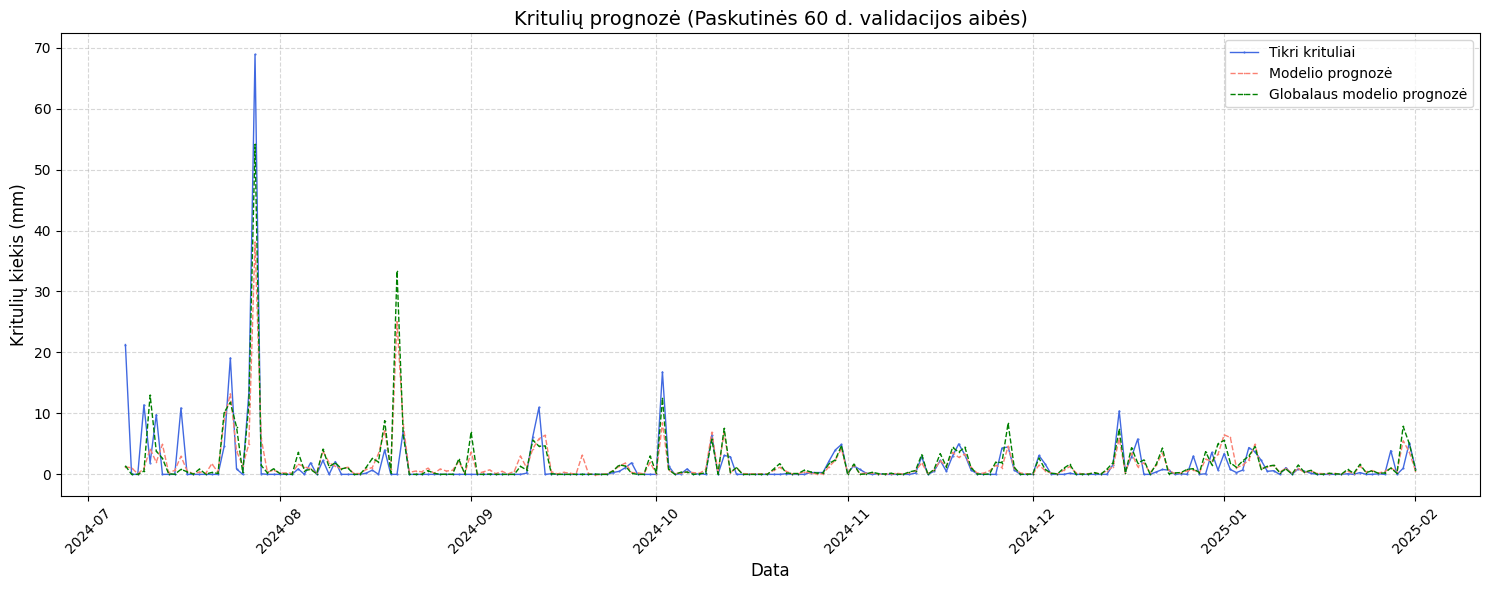

In [81]:
plot_df = val[['observationTime', 'target_precipitation']].copy()
plot_df['prediction'] = val_preds
plot_df = plot_df.sort_values('observationTime')

plt.figure(figsize=(15, 6))

plt.plot(recent_df['observationTime'], recent_df['target_precipitation'], 
         label='Tikri krituliai', color='royalblue', linewidth=1, marker='o', markersize=0.5)

plt.plot(recent_df['observationTime'], recent_df['prediction'], 
         label='Modelio prognozė', color='salmon', linestyle='--', linewidth=1, marker='x', markersize=0.5)

plt.plot(recent_df['observationTime'], recent_df['tp'], 
         label='Globalaus modelio prognozė', color='green', linestyle='--', linewidth=1, marker='x', markersize=0.5)

plt.title('Kritulių prognozė (Paskutinės 60 d. validacijos aibės)', fontsize=14)
plt.ylabel('Kritulių kiekis (mm)', fontsize=12)
plt.xlabel('Data', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()